In [1]:
import os

BASE_PATH = "/mnt/d/projects/thyroid_cancer_detection/archive"
DATASET_PATH = os.path.join(BASE_PATH, "Thyroid Data")

In [2]:
import os
import pandas as pd
categories = [0, 1]

image_paths = []
labels = []

for cat in categories:
    labelled_path = os.path.join(DATASET_PATH, str(cat))
    for img_name in os.listdir(labelled_path):
        if img_name.lower().endswith((".png", ".jpeg", ".jpg")):
            image_path = os.path.join(labelled_path, img_name)
            image_paths.append(image_path)
            labels.append(int(cat))

df = pd.DataFrame({"img_path" : image_paths, "label" : labels})
df.head()

,img_path,label
0,/mnt/d/projects/thyroid_cancer_detection/archi...,0
1,/mnt/d/projects/thyroid_cancer_detection/archi...,0
2,/mnt/d/projects/thyroid_cancer_detection/archi...,0
3,/mnt/d/projects/thyroid_cancer_detection/archi...,0
4,/mnt/d/projects/thyroid_cancer_detection/archi...,0


In [3]:
print(len(df))
print(df["label"].value_counts())
print(df.shape)

3115
label
0    1905
1    1210
Name: count, dtype: int64
(3115, 2)


### Data Visualization

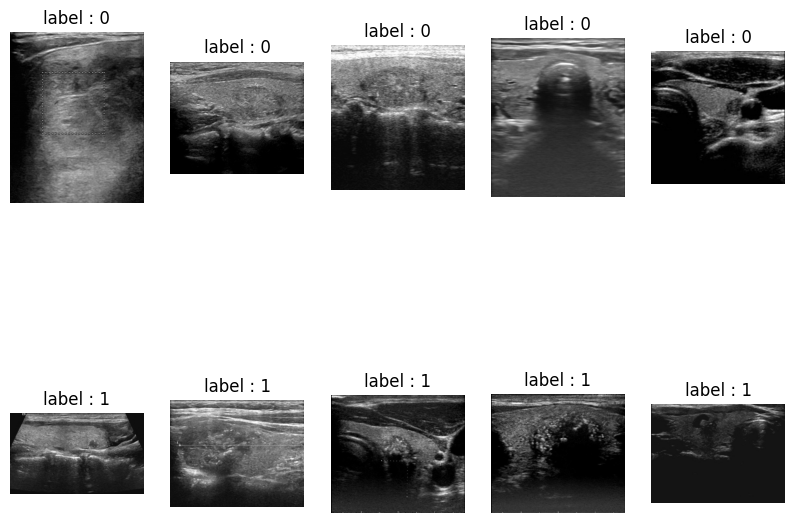

In [4]:
import cv2
import matplotlib.pyplot as plt

num_images = 5
categories = ["0", "1"]

plt.figure(figsize= (10, 8))

for i, category in enumerate(categories):
    category_int = int(category)
    category_images = df[df["label"] == category_int]["img_path"].iloc[:num_images]

    for j, image_path in enumerate(category_images):
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(categories), num_images, i * num_images + j + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"label : {category}")

        else:
            print("No Image found")

plt.tight_layout
plt.show()

### Data Augmentation

In [5]:
majority_class = df[df["label"] == 0]
minority_class = df[df["label"] == 1]

minority_oversampled = minority_class.sample(n = len(majority_class), replace= True, random_state= 42)

df_resampled = pd.concat([majority_class, minority_oversampled]).sample(frac=1, random_state= 42).reset_index(drop= True)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_resampled["category_encoded"] = encoder.fit_transform(df_resampled["label"])

print(df_resampled['label'].value_counts())
print(df_resampled['label'].nunique())
print(len(df_resampled))

label
0    1905
1    1905
Name: count, dtype: int64
2
3810


### Model Training

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import  regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-05-17 10:57:24.762108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779015444.783272   18768 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779015444.790191   18768 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779015444.808373   18768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779015444.808396   18768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779015444.808398   18768 computation_placer.cc:177] computation placer alr

### Train Test Val Split

In [7]:
train_df, temp_df = train_test_split(
    df_resampled, 
    test_size= 0.2,
    shuffle= True,
    random_state= 42,
    stratify= df_resampled["category_encoded"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size= 0.5,
    stratify= temp_df["category_encoded"],
    shuffle = True,
    random_state= 42
)

train_df["category_encoded"] = train_df["category_encoded"].astype(str)
val_df["category_encoded"] = val_df["category_encoded"].astype(str)
test_df["category_encoded"] = test_df["category_encoded"].astype(str)

print(len(train_df))
print(len(val_df))
print(len(test_df))
print(train_df["category_encoded"].dtype)

3048
381
381
str


In [8]:
batch_size = 2
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

train_gen = ImageDataGenerator(rescale= 1./255)
test_gen = ImageDataGenerator(rescale = 1./255)

train_gen_new = train_gen.flow_from_dataframe(
    train_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
valid_gen_new = test_gen.flow_from_dataframe(
    val_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
test_gen_new = test_gen.flow_from_dataframe(
    test_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = False,
    batch_size = batch_size
)

Found 3048 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.


In [9]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for Tensorflow")
    except RuntimeError as e:
        print(e)

GPU is set for Tensorflow


In [10]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

In [11]:
import sys
sys.path.append(r"/mnt/d/projects/thyroid_cancer_detection/")

### Model Training

In [12]:
from src.fibonacci_net import FibonacciNet

model = FibonacciNet()

dummy = tf.random.normal((1, 224, 224, 3))

output = model(dummy)
print(output)

I0000 00:00:1779015456.376414   18768 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1779015458.051790   18768 cuda_dnn.cc:529] Loaded cuDNN version 91002


tf.Tensor([[0.508859]], shape=(1, 1), dtype=float32)


In [13]:
model.summary()

Model: "fibonacci_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fibonacci_conv_block            │ ?                      │           672 │
│ (FibonacciConvBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fibonacci_conv_block_1          │ ?                      │         6,596 │
│ (FibonacciConvBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pcb1 (PCB1)                     │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fibonacci_conv_block_2          │ ?                      │        17,105 │
│ (FibonacciConvBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pcb2 (PCB2)                     │ ?                      │        12,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fibonacci_conv_block_3          │ ?                      │        71,734 │
│ (FibonacciConvBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fibonacci_conv_block_4          │ ?                      │       147,168 │
│ (FibonacciConvBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dwsc_block (DWSCBlock)          │ ?                      │        36,157 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dwsc_block_1 (DWSCBlock)        │ ?                      │       182,227 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │           378 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 474,037 (1.81 MB)

 Trainable params: 472,083 (1.80 MB)

 Non-trainable params: 1,954 (7.63 KB)

In [22]:
from src.fibonacci_net import *

model = tf.keras.models.load_model(
    "/mnt/d/projects/thyroid_cancer_detection/models/thyroid_fibonaccinet_best.keras",

    custom_objects={
        "FibonacciNet": FibonacciNet,
        "FibonacciConvBlock": FibonacciConvBlock,
        "Avg2MaxPooling": Avg2MaxPooling,
        "PCB1": PCB1,
        "PCB2": PCB2,
        "DWSCBlock": DWSCBlock
    }
)

In [23]:
from sklearn.metrics import classification_report

preds = model.predict(test_gen_new)

y_pred = (preds > 0.5).astype(int)

print(classification_report(
    test_gen_new.classes,
    y_pred
))

191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       191
           1       0.84      0.88      0.86       190

    accuracy                           0.86       381
   macro avg       0.86      0.86      0.86       381
weighted avg       0.86      0.86      0.86       381



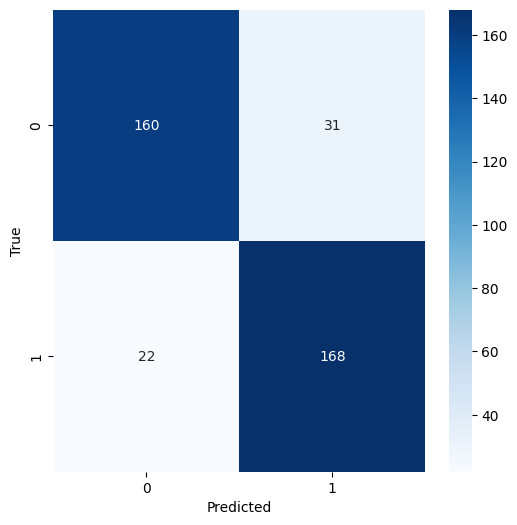

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_gen_new.classes,
    y_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

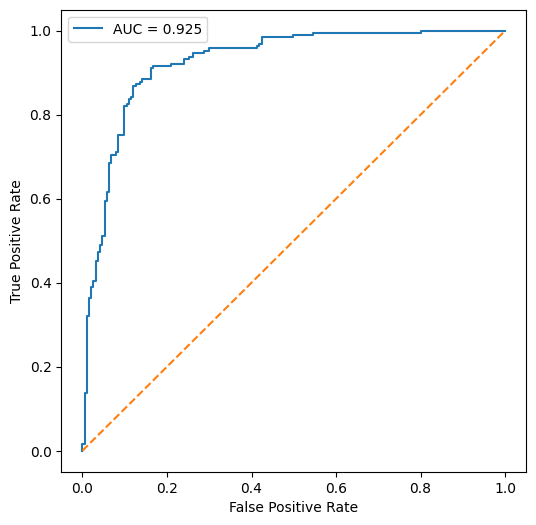

In [25]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    test_gen_new.classes,
    preds
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

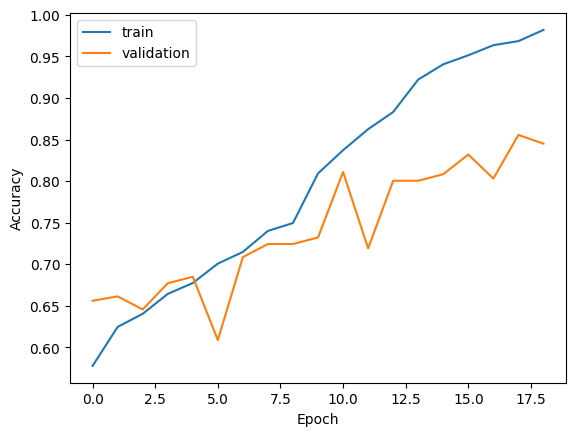

In [27]:
import pickle

with open("/mnt/d/projects/thyroid_cancer_detection/models/history.pkl", "rb") as f:
    history = pickle.load(f)
    
plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])

plt.legend([
    "train",
    "validation"
])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

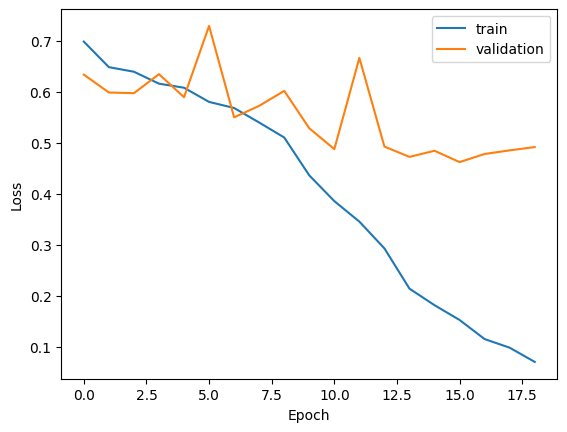

In [28]:
plt.plot(history["loss"])
plt.plot(history["val_loss"])

plt.legend([
    "train",
    "validation"
])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()